<h1> <b>DEPENDENCIES</b> </h1>

In [1]:
    import os
    from pathlib import Path
    import matplotlib.pyplot as plt
    import random
    import numpy as np
    import tensorflow as tf
    from PIL import Image
    from tensorflow.keras.applications.vgg16 import VGG16
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.layers import *
    from tensorflow.keras.models import Model

In [2]:
# Resolve the dataset location whether the notebook is launched from the repo root or Notebooks/
BASE_DIR = Path.cwd()
if not (BASE_DIR / "cell_images").exists():
    BASE_DIR = BASE_DIR.parent

DATA_DIR = BASE_DIR / "cell_images"
PARASITIZED_DIR = DATA_DIR / "Parasitized"
UNINFECTED_DIR = DATA_DIR / "Uninfected"

# Directory for Parasitized images
parasitic = os.listdir(PARASITIZED_DIR)

# Directory for Uninfected images
uninfected = os.listdir(UNINFECTED_DIR)

In [3]:
len(parasitic)  #total images of Parasitized images

15532

<h1> <b>DATA VISUALIZATION</b> </h1>

<h2> <b> PARASITIZED IMAGES</b> </h2>

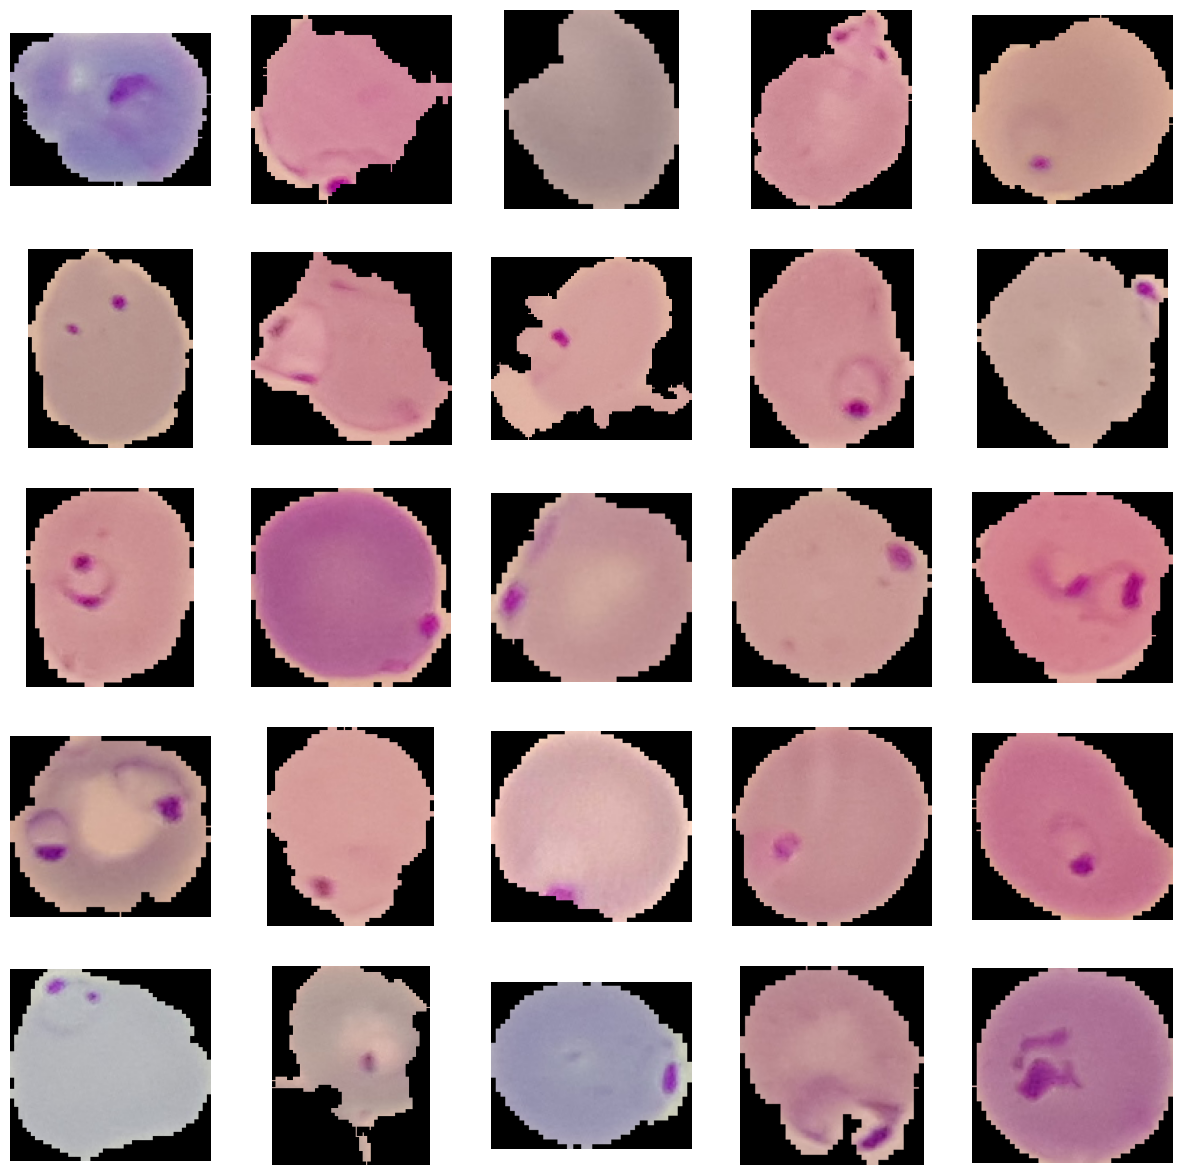

In [4]:
#taking random 25 random samples from PARASITIZED folder
filenames = random.sample(os.listdir(PARASITIZED_DIR),25)   
plt.figure(figsize=(15, 15)) 

#Displaying 25 sample
for i in range(1, len(filenames)+1):
    row = i
    image = plt.imread(str(PARASITIZED_DIR / filenames[i-1]))
    plt.subplot(5, 5, row)
    plt.axis("off")
    plt.imshow(image)
plt.show()


<h2><b>UNINFECTED IMAGES</b></h2>





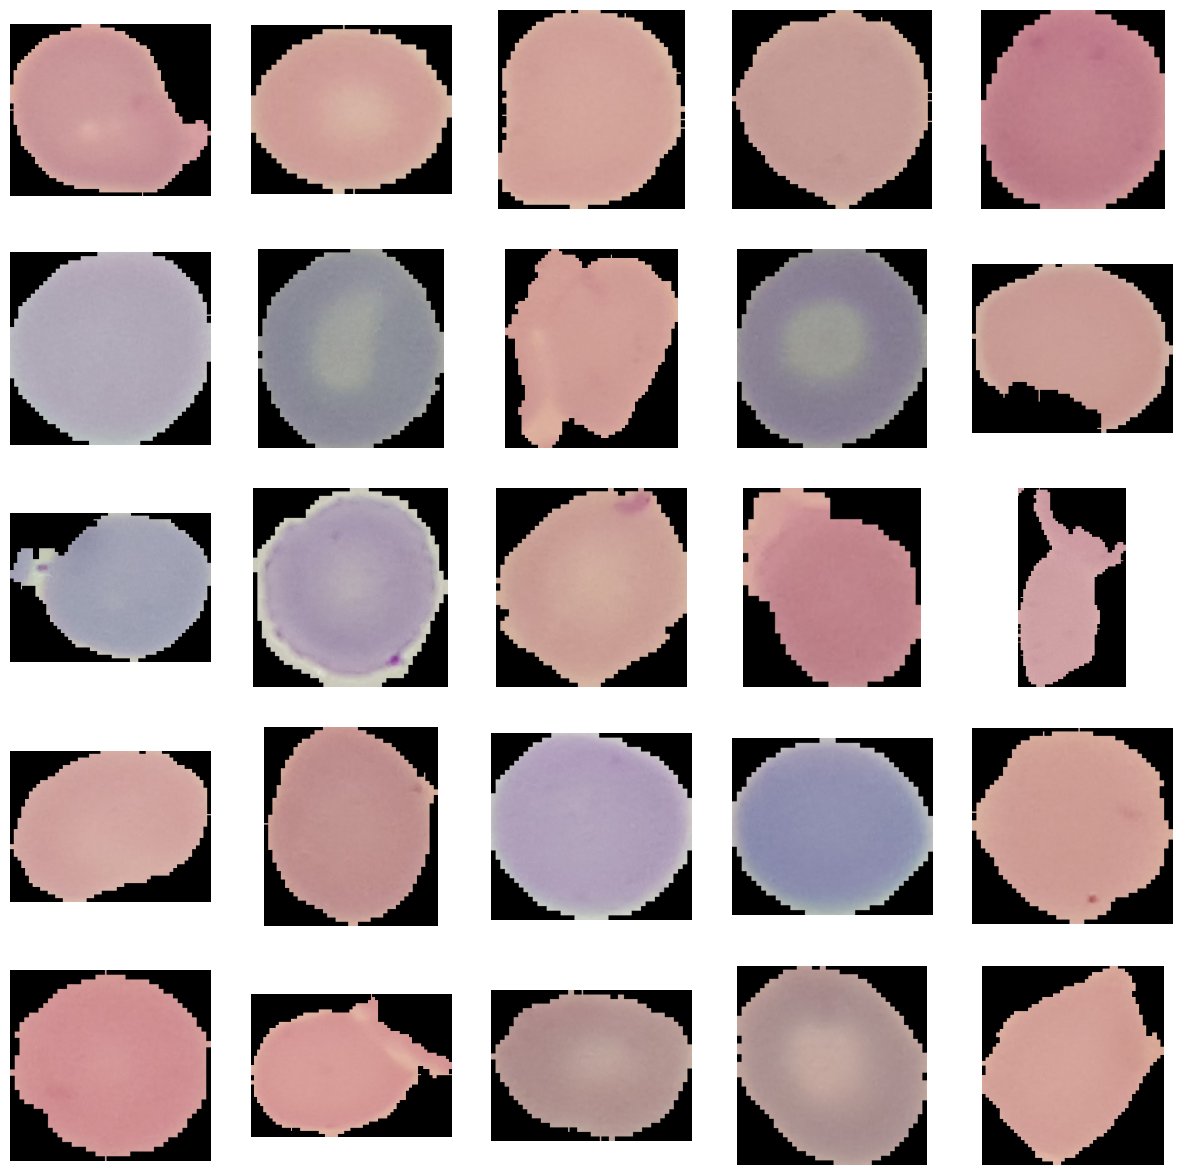

In [5]:
#taking random 25 random samples from UNINFECTED folder
filenames = random.sample(os.listdir(UNINFECTED_DIR),25)
plt.figure(figsize=(15, 15)) 

#Displaying 25 sample
for i in range(1, len(filenames)+1):
    row = i
    image = plt.imread(str(UNINFECTED_DIR / filenames[i-1]))
    plt.subplot(5, 5, row)
    plt.axis("off")
    plt.imshow(image)
plt.show()


<h1> <b>DATA PREPROCESSING</b> </h1>

<p> <b>DATA AUGMENTATION</b> <br>
We are doing data augmentation and splitting the data in training and validation set.</p>

*   Setting split equal to 0.05%
*   Shape of image is (64,64,3)




In [6]:
IMG_SIZE = (64, 64)
BATCH_SIZE = 32
VAL_SPLIT = 0.05
ALLOWED_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".gif"}

def load_image(path):
    image = Image.open(path).convert("RGB").resize(IMG_SIZE)
    return np.asarray(image, dtype=np.float32) / 255.0

def build_dataset(directory):
    class_names = ["Parasitized", "Uninfected"]
    filepaths = []
    labels = []
    for label, class_name in enumerate(class_names):
        class_dir = Path(directory) / class_name
        for filename in os.listdir(class_dir):
            path = class_dir / filename
            if path.is_file() and path.suffix.lower() in ALLOWED_EXTENSIONS:
                filepaths.append(str(path))
                labels.append(label)
    return np.array(filepaths), np.array(labels, dtype=np.float32), class_names

class MalariaSequence(tf.keras.utils.Sequence):
    def __init__(self, filepaths, labels, batch_size=BATCH_SIZE, shuffle=True):
        self.filepaths = np.array(filepaths)
        self.labels = np.array(labels, dtype=np.float32)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.filepaths))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.filepaths) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_paths = self.filepaths[batch_indices]
        batch_labels = self.labels[batch_indices]
        batch_images = np.stack([load_image(path) for path in batch_paths], axis=0)
        return batch_images, batch_labels

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

filepaths, labels, class_names = build_dataset(DATA_DIR)
rng = np.random.default_rng(42)
indices = np.arange(len(filepaths))
rng.shuffle(indices)
split_index = int(len(indices) * (1 - VAL_SPLIT))
train_indices = indices[:split_index]
val_indices = indices[split_index:]

train = MalariaSequence(filepaths[train_indices], labels[train_indices], batch_size=BATCH_SIZE, shuffle=True)
test = MalariaSequence(filepaths[val_indices], labels[val_indices], batch_size=BATCH_SIZE, shuffle=False)

print(f"Classes: {class_names}")
print(f"Training samples: {len(train_indices)}")
print(f"Validation samples: {len(val_indices)}")

Classes: ['Parasitized', 'Uninfected']
Training samples: 27844
Validation samples: 1466


<h1> <b>BUILDING MODEL USING VGG16 </b> </h1>

<h3> <b>ABOUT VGG16</b> </h3>

*   VGG16 is a convolution neural net(CNN) architecture which was used to win ILSVR(Imagenet) competition in 2014.
*   By default, it loads weights pre-trained on ImageNet.
*   The default input size for this model is 224x224.



In [7]:
#using imagenet weights and setting the shape as (64,64,3) as our image is of 64,64 and has 3 channels
try:
    model = VGG16(include_top=False, weights="imagenet", input_shape=(64,64,3))
except Exception:
    # Fall back to random initialization if the pretrained weights are unavailable offline.
    model = VGG16(include_top=False, weights=None, input_shape=(64,64,3))
model.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 64, 64, 3)]       0         
                                                                 
 block1_conv1 (Conv2D)       (None, 64, 64, 64)        1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 64, 64, 64)        36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 32, 32, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 32, 32, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 32, 32, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 16, 16, 128)       0     

In [8]:
#Printing the names of all the layers present in the model and setting trainable as False

for i in range(len(model.layers)):
  print(i,model.layers[i])
  model.layers[i].trainable=False

0 <keras.engine.input_layer.InputLayer object at 0x0000024FBE1885B0>
1 <keras.layers.convolutional.conv2d.Conv2D object at 0x0000024FBE188C10>
2 <keras.layers.convolutional.conv2d.Conv2D object at 0x0000024FBE189690>
3 <keras.layers.pooling.max_pooling2d.MaxPooling2D object at 0x0000024FBE189C60>
4 <keras.layers.convolutional.conv2d.Conv2D object at 0x0000024FBE18BEB0>
5 <keras.layers.convolutional.conv2d.Conv2D object at 0x0000024FBE189570>
6 <keras.layers.pooling.max_pooling2d.MaxPooling2D object at 0x0000024FBE18A8F0>
7 <keras.layers.convolutional.conv2d.Conv2D object at 0x0000024FBE1885E0>
8 <keras.layers.convolutional.conv2d.Conv2D object at 0x0000024FBE1B5660>
9 <keras.layers.convolutional.conv2d.Conv2D object at 0x0000024FBE1B47C0>
10 <keras.layers.pooling.max_pooling2d.MaxPooling2D object at 0x0000024FBE1B7C10>
11 <keras.layers.convolutional.conv2d.Conv2D object at 0x0000024FBE1B7D30>
12 <keras.layers.convolutional.conv2d.Conv2D object at 0x0000024FBE1B5960>
13 <keras.layers.co

In [9]:
# Adding the custom layers to the model

l = GlobalAveragePooling2D()(model.output)
l2 = Dropout(0.2)(l)
l3 = Dense(128, activation="relu")(l2)
l4 = Dropout(0.2)(l3)
l5 = Dense(1,activation="sigmoid")(l4)

#creating the new model by adding the VGG model's input as Input of the new model and l5 layer of our custom model as Output.
new_model = Model(inputs= model.input, outputs= l5)


In [10]:
# New Model
new_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 64, 64, 3)]       0         
                                                                 
 block1_conv1 (Conv2D)       (None, 64, 64, 64)        1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 64, 64, 64)        36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 32, 32, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 32, 32, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 32, 32, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 16, 16, 128)       0     

<h2> <b> Compiling the new model </b> </h2>

In [11]:
# Using Adam as the optimizer and loss as binary cross entropy as there are only 2 classes
adam = Adam(learning_rate=0.001)
new_model.compile(optimizer=adam,loss="binary_crossentropy",metrics=['accuracy'])

<h2> <b> Training the new model </b> </h2>

In [ ]:
his = new_model.fit(train,epochs=50,validation_data=test,workers=0)

Epoch 1/50
 82/871 [=>............................] - ETA: 9:43 - loss: 0.4681 - accuracy: 0.7828

<h2> <b> Plotting the Accuracy, Validation Accuracy, Loss and Validation Loss </b> </h2>

In [ ]:
try:
    plt.style.use("seaborn-v0_8")
except OSError:
    plt.style.use("seaborn")
plt.plot(his.history['accuracy'],label="acc")
plt.plot(his.history['val_accuracy'],label="val_acc")
plt.plot(his.history['loss'],label="loss")
plt.plot(his.history['val_loss'],label="val_loss")
plt.legend()
plt.plot()

<h2> <b> Testing the model </b> </h2>

In [ ]:
#testing on train set
new_model.evaluate(train)  

In [ ]:
#testing  on test set
print("TESTING ACCURACY :", new_model.evaluate(test)[1])  